# Laboratorium 4
Natalia Ślepowrońska 318847

Na początki zaimportowano biblioteki oraz sprawdzono GPU.

In [96]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import os
import sys

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

Używane urządzenie: cpu


## 1. Wprowadzenie do przepływu optycznego

Poniżej znajdują się niezbędne funkcje do załadowania plików i wizualizacji.

In [97]:
def load_middlebury_images(path1, path2):
    img1 = cv2.imread(path1, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(path2, cv2.IMREAD_GRAYSCALE)
    return img1, img2

def load_middlebury_flow(path):
    with open(path, 'rb') as f:
        magic = np.fromfile(f, np.float32, count=1)[0]
        if 202021.25 != magic:
            print('Error reading flow file %s' % path)
            return None
        else:
            w = np.fromfile(f, np.int32, count=1)[0]
            h = np.fromfile(f, np.int32, count=1)[0]
            data = np.fromfile(f, np.float32, count=2*w*h)
            # Reshape data into 3D array (columns, rows, bands)
            flow = np.resize(data, (h, w, 2))
            return flow

In [98]:
def visualize_flow_hsv(flow, title="Optical Flow HSV"):
    h, w = flow.shape[:2]
    flow[flow[:, :, 0] > 100] = 0.0
    flow[flow[:, :, 1] > 100] = 0.0
    # Oblicz magnitude i kąt
    magnitude, angle = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    # Przeskaluj magnitude do zakresu 0-1
    magnitude = cv2.normalize(magnitude, None, 0, 1, cv2.NORM_MINMAX)
    # Konwertuj kąt na stopnie i znormalizuj do 0-180
    angle = angle * 180 / np.pi / 2
    # Stwórz obraz HSV
    hsv = np.zeros((h, w, 3), dtype=np.uint8)
    hsv[..., 0] = angle
    hsv[..., 1] = 255
    hsv[..., 2] = magnitude*255
    # Konwertuj HSV na RGB
    rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
    plt.imshow(rgb)
    plt.title(title)
    plt.show()

In [99]:
def visualize_images(img1, img2):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img1, cmap='gray')
    plt.title('Obraz 1')
    plt.subplot(1, 2, 2)
    plt.imshow(img2, cmap='gray')
    plt.title('Obraz 2')
    plt.show()

Przyszłe analizy zostaną wykonane dla poniższych 5 przypadków.

In [100]:
image1_path1 = "RubberWhale/frame10.png"  
image1_path2 = "RubberWhale/frame11.png"  
flow1_path = "RubberWhale/flow10.flo"    

image2_path1 = "Hydrangea/frame10.png"  
image2_path2 = "Hydrangea/frame11.png"  
flow2_path = "Hydrangea/flow10.flo"    

image3_path1 = "Urban2/frame10.png"  
image3_path2 = "Urban2/frame11.png"  
flow3_path = "Urban2/flow10.flo"    

image4_path1 = "Venus/frame10.png"  
image4_path2 = "Venus/frame11.png"  
flow4_path = "Venus/flow10.flo"    

image5_path1 = "Grove2/frame10.png"  
image5_path2 = "Grove2/frame11.png"  
flow5_path = "Grove2/flow10.flo"    

In [101]:
img11, img12 = load_middlebury_images(image1_path1, image1_path2)
gt_flow1 = load_middlebury_flow(flow1_path)

img21, img22 = load_middlebury_images(image2_path1, image2_path2)
gt_flow2 = load_middlebury_flow(flow2_path)

img31, img32 = load_middlebury_images(image3_path1, image3_path2)
gt_flow3 = load_middlebury_flow(flow3_path)

img41, img42 = load_middlebury_images(image4_path1, image4_path2)
gt_flow4 = load_middlebury_flow(flow4_path)

img51, img52 = load_middlebury_images(image5_path1, image5_path2)
gt_flow5 = load_middlebury_flow(flow5_path)

Wizualizacja przepływów oraz obrazów została umieszczona poniżej.

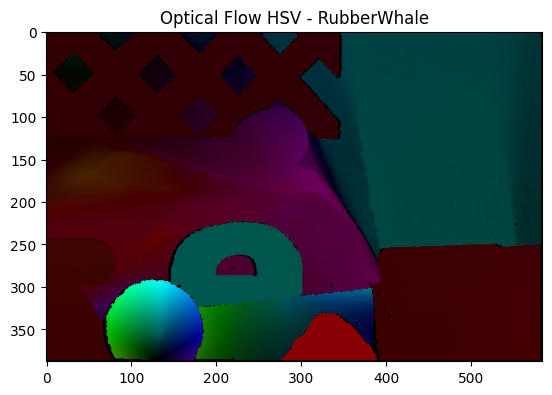

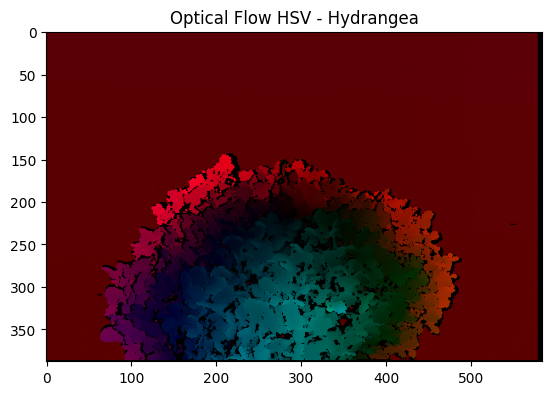

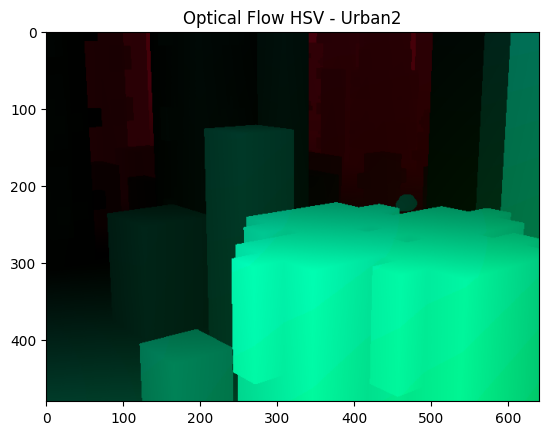

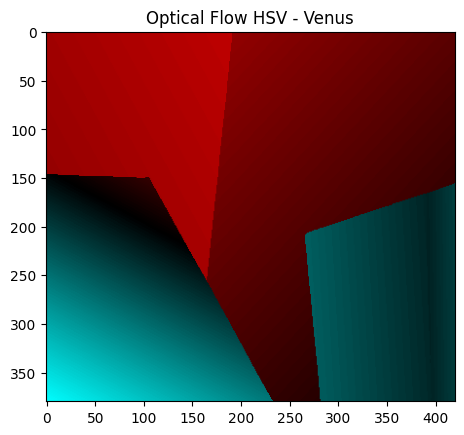

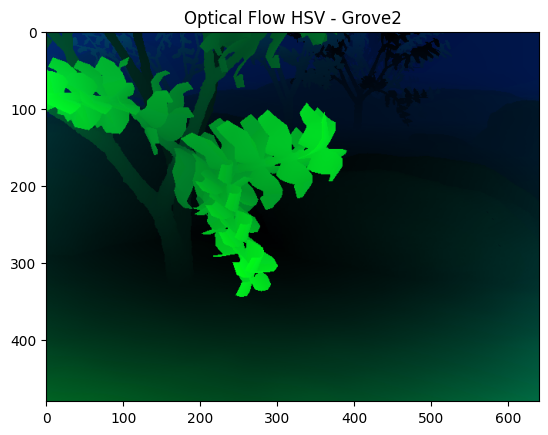

In [102]:
visualize_flow_hsv(gt_flow1, title="Optical Flow HSV - RubberWhale")
visualize_flow_hsv(gt_flow2, title="Optical Flow HSV - Hydrangea")
visualize_flow_hsv(gt_flow3, title="Optical Flow HSV - Urban2")
visualize_flow_hsv(gt_flow4, title="Optical Flow HSV - Venus")
visualize_flow_hsv(gt_flow5, title="Optical Flow HSV - Grove2")

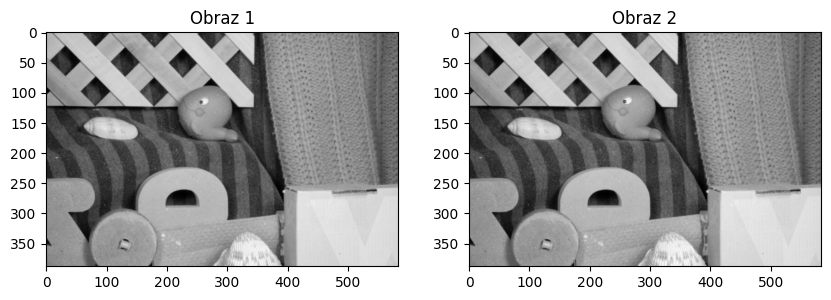

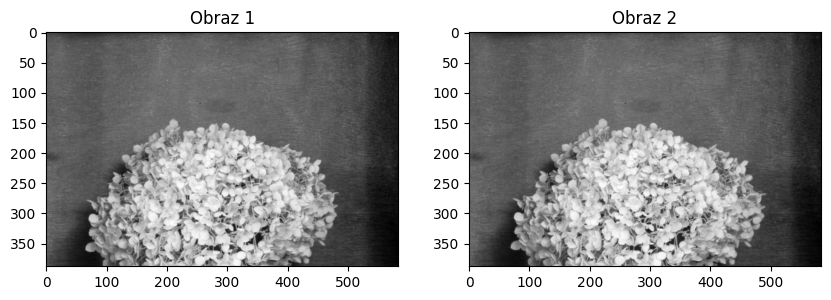

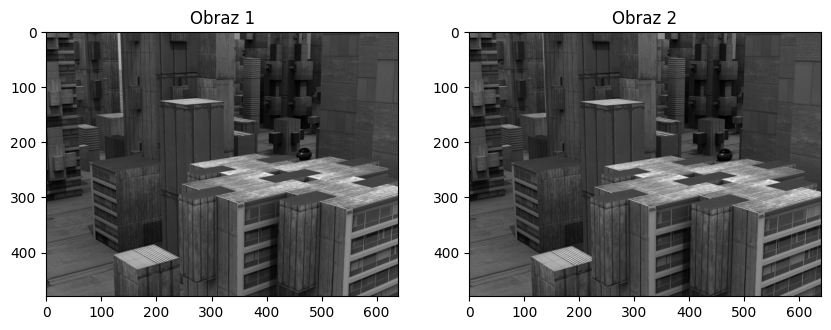

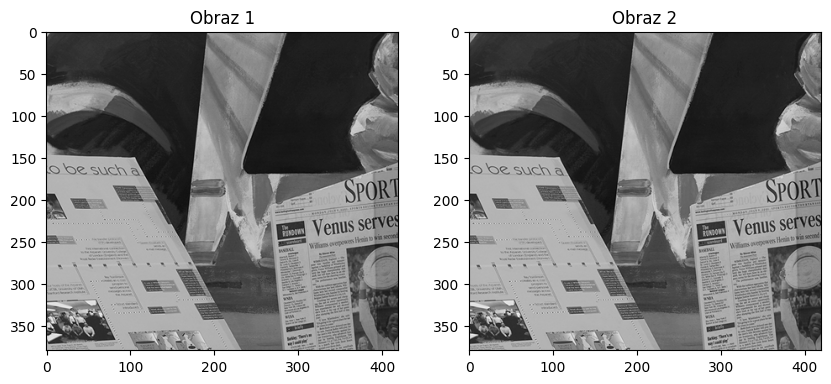

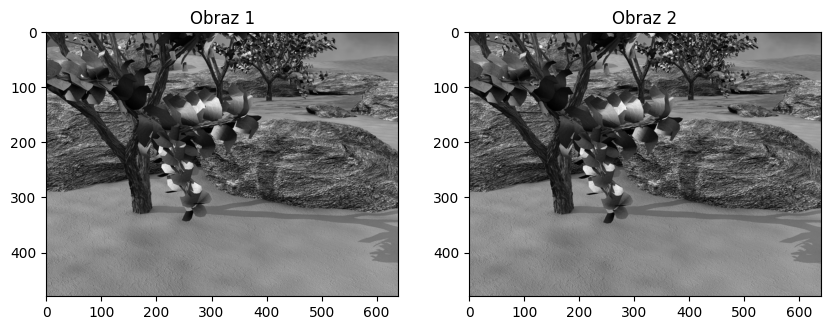

In [103]:
visualize_images(img11, img12)
visualize_images(img21, img22)
visualize_images(img31, img32)
visualize_images(img41, img42)
visualize_images(img51, img52)

W tej części ćwiczenia udało się załadować odpowiednie pliki potrzebne dla dalszej części ćwiczenia oraz zwizualizować przygotowane wcześniej przepływy optyczne.

## 2. Klasyczne metody wyznaczania przepływu optycznego


### 2.1 Algorytm Lucas-Kanade

In [104]:
def lucas_kanade(img1, img2, window_size=15, max_level=3, iterations=30, epsilon=0.01):
    """
    Wyznacza przepływ optyczny za pomocą algorytmu Lucas-Kanade.

    Args:
        img1 (numpy.ndarray): Pierwszy obraz (skala szarości).
        img2 (numpy.ndarray): Drugi obraz (skala szarości).
        window_size (int): Rozmiar okna poszukiwania.
        max_level (int): Maksymalny poziom piramidy obrazów.
        iterations (int): Maksymalna liczba iteracji.
        epsilon (float): Kryterium zbieżności dla iteracji.

    Returns:
        numpy.ndarray: Pole przepływu optycznego (wysokość x szerokość x 2).
    """
    h, w = img1.shape
    flow = np.zeros((h, w, 2), dtype=np.float32)

    # Parametry algorytmu Lucas-Kanade
    lk_params = dict(winSize=(window_size, window_size),
                       maxLevel=max_level,
                       criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, iterations, epsilon))

    # Wykryj punkty charakterystyczne (np. rogi Shi-Tomasi)
    p0 = cv2.goodFeaturesToTrack(img1, maxCorners=2000, qualityLevel=0.01, minDistance=10)
    if p0 is None:
        return flow
    print(p0.size)
    # Oblicz przepływ optyczny
    p1, st, err = cv2.calcOpticalFlowPyrLK(img1, img2, p0, None, **lk_params)

    # Wybierz tylko punkty, dla których przepływ został znaleziony
    if p1 is not None and st is not None:
        good_new = p1[st == 1]
        good_old = p0[st == 1]

        # Przypisz wektory przepływu do odpowiednich pikseli
        for i, (new, old) in enumerate(zip(good_new, good_old)):
            a, b = new.ravel()
            c, d = old.ravel()
            flow[int(d), int(c)] = [a - c, b - d]  # Zmiana kolejności (x, y) -> (wsp. kol, wsp. wiersz)

    return flow

Wyniki obliczeń przepływu optycznego dla 5 przypadków.

In [105]:
lk_flow1 = lucas_kanade(img11, img12, window_size=15, max_level=3, iterations=30, epsilon=0.01)
lk_flow2 = lucas_kanade(img21, img22, window_size=15, max_level=3, iterations=30, epsilon=0.01)
lk_flow3 = lucas_kanade(img31, img32, window_size=15, max_level=3, iterations=30, epsilon=0.01)
lk_flow4 = lucas_kanade(img41, img42, window_size=15, max_level=3, iterations=30, epsilon=0.01)
lk_flow5 = lucas_kanade(img51, img52, window_size=15, max_level=3, iterations=30, epsilon=0.01)

1652
1210
1966
878
1986


Wizualizacja przepływów poniżej.

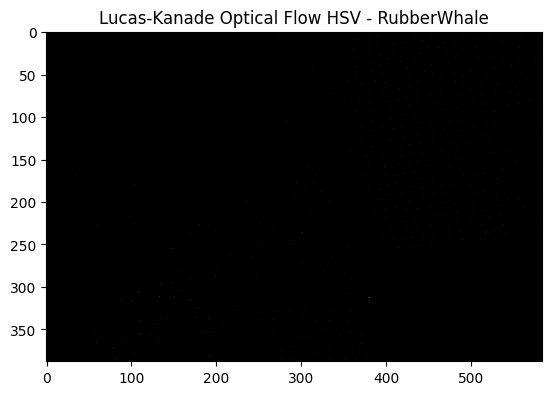

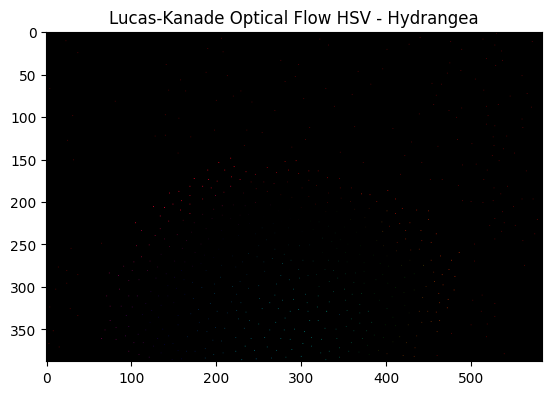

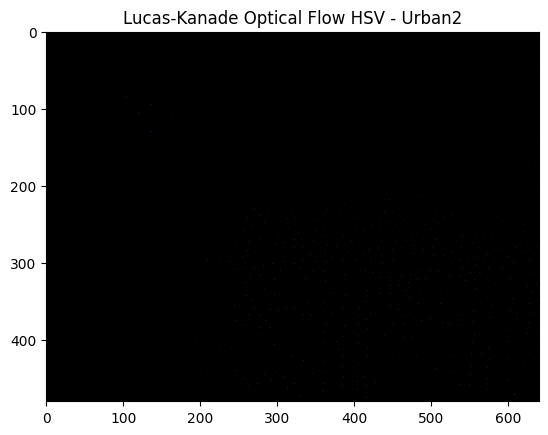

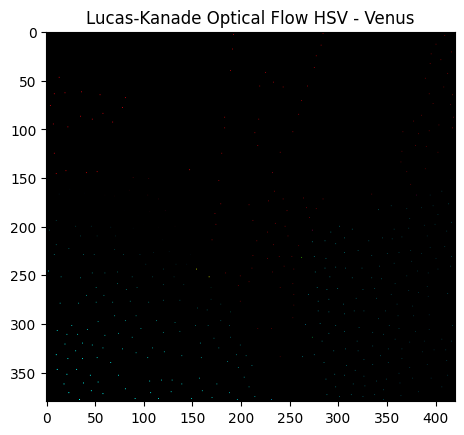

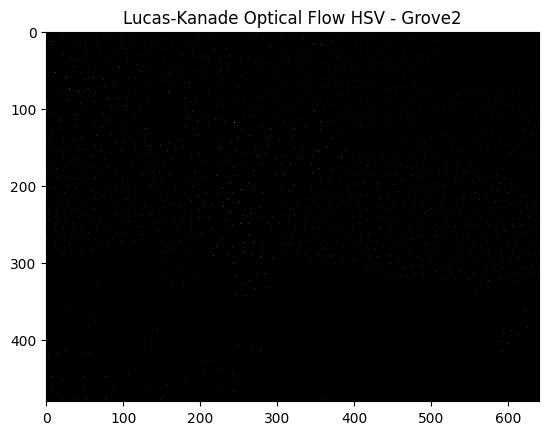

In [106]:
visualize_flow_hsv(lk_flow1, "Lucas-Kanade Optical Flow HSV - RubberWhale")
visualize_flow_hsv(lk_flow2, "Lucas-Kanade Optical Flow HSV - Hydrangea")
visualize_flow_hsv(lk_flow3, "Lucas-Kanade Optical Flow HSV - Urban2")
visualize_flow_hsv(lk_flow4, "Lucas-Kanade Optical Flow HSV - Venus")
visualize_flow_hsv(lk_flow5, "Lucas-Kanade Optical Flow HSV - Grove2")

Tylko pojedyncze piksele mają niezerowy przepływ, cała reszta posiada wartość zero. Dlatego powyższe wizualizacje HSV wyglądają jak czarny obraz.

Wartości błędów dla Lucas-Kanade dla 5 przypadków dla zadanych wyżej parametrów.

In [107]:
if gt_flow is not None:
    lk_aee = calculate_aee(lk_flow1, gt_flow1)
    lk_ae = calculate_angle_error(lk_flow1, gt_flow1)
    print(f"Lucas-Kanade - {'RubberWhale':15} AEE: {lk_aee:.3f}, AE: {lk_ae:.3f}")

if gt_flow is not None:
    lk_aee = calculate_aee(lk_flow2, gt_flow2)
    lk_ae = calculate_angle_error(lk_flow2, gt_flow2)
    print(f"Lucas-Kanade - {'Hydrangea':15} AEE: {lk_aee:.3f}, AE: {lk_ae:.3f}")

if gt_flow is not None:
    lk_aee = calculate_aee(lk_flow3, gt_flow3)
    lk_ae = calculate_angle_error(lk_flow3, gt_flow3)
    print(f"Lucas-Kanade - {'Urban2':15} AEE: {lk_aee:.3f}, AE: {lk_ae:.3f}")

if gt_flow is not None:
    lk_aee = calculate_aee(lk_flow4, gt_flow4)
    lk_ae = calculate_angle_error(lk_flow4, gt_flow4)
    print(f"Lucas-Kanade - {'Venus':15} AEE: {lk_aee:.3f}, AE: {lk_ae:.3f}")

if gt_flow is not None:
    lk_aee = calculate_aee(lk_flow5, gt_flow5)
    lk_ae = calculate_angle_error(lk_flow5, gt_flow5)
    print(f"Lucas-Kanade - {'Grove2':15} AEE: {lk_aee:.3f}, AE: {lk_ae:.3f}")

Lucas-Kanade - RubberWhale     AEE: 1.232, AE: 89.708
Lucas-Kanade - Hydrangea       AEE: 3.481, AE: 89.803
Lucas-Kanade - Urban2          AEE: 8.369, AE: 89.747
Lucas-Kanade - Venus           AEE: 3.794, AE: 89.779
Lucas-Kanade - Grove2          AEE: 3.081, AE: 89.730


Średni błąd końcowy wektora (AEE) jest wyraźny i jest zależny od przypadku. Pokazuje to, że metoda Lucas‑Kanade nie radzi sobie dobrze z dokładnym odwzorowaniem wielkości ruchu, zwłaszcza w bardziej złożonych sekwencjach takich jak Urban2.

Błąd kierunku wektora przepływu (AE) wynoszący około 90 stopni oznacza, że kierunek ruchu wyznaczony przez algorytm jest niemal prostopadły do kierunku rzeczywistego. W praktyce świadczy to o tym, że metoda Lucas‑Kanade nie potrafi poprawnie określić orientacji wektora przepływu i jej wynik jest w dużej mierze przypadkowy.

### 2.2 Algorytm Farneback

#### Domyślne wartości parametrów obliczeń przepływu optycznego

In [108]:
def farneback(img1, img2, pyr_scale=0.5, levels=3, winsize=15, iterations=3, poly_n=5, poly_sigma=1.2):
    """
    Wyznacza przepływ optyczny za pomocą algorytmu Farneback.
    Args:
        img1 (numpy.ndarray): Pierwszy obraz (skala szarości).
        img2 (numpy.ndarray): Drugi obraz (skala szarości).
        pyr_scale (float): Skala, o jaką zmniejszany jest obraz na każdym poziomie piramidy.
        levels (int): Liczba poziomów piramidy.
        winsize (int): Averaging window size.
        iterations (int): Liczba iteracji.
        poly_n (int): Rozmiar sąsiedztwa używany do znalezienia wielomianu.
        poly_sigma (float): Standardowe odchylenie Gaussa używane do wygładzania pochodnych.
    Returns:
        numpy.ndarray: Pole przepływu optycznego (wysokość x szerokość x 2).
    """
    flow = cv2.calcOpticalFlowFarneback(img1, img2, None, pyr_scale, levels, winsize, iterations, poly_n, poly_sigma, 0)
    return flow

Poniżej obliczenia oraz wizualizacja dla 5 przypadków dla metody Farneback.

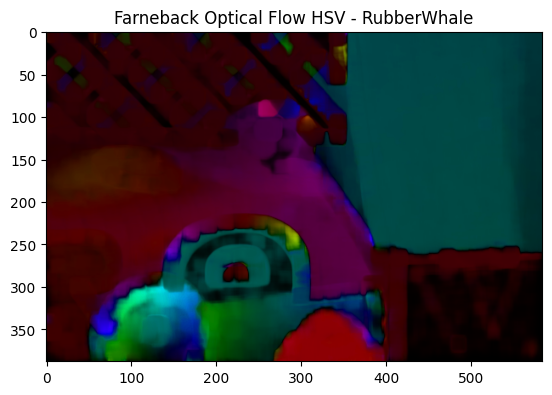

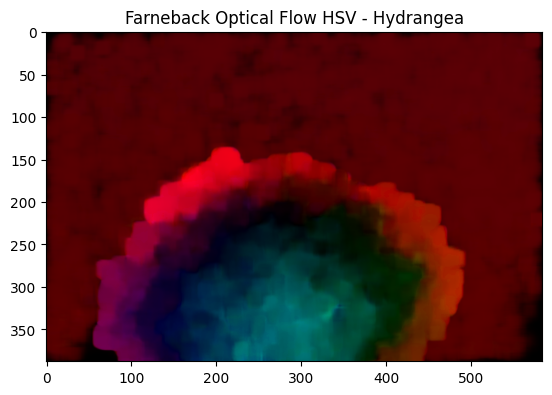

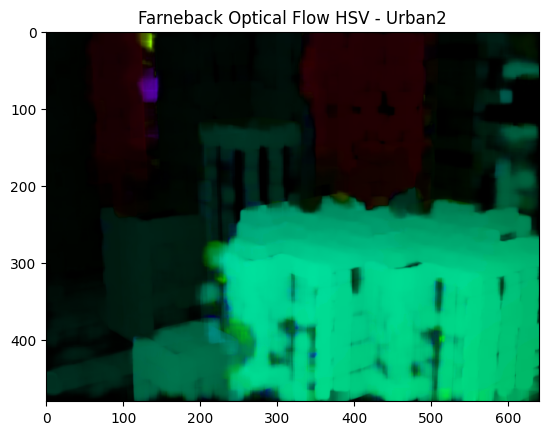

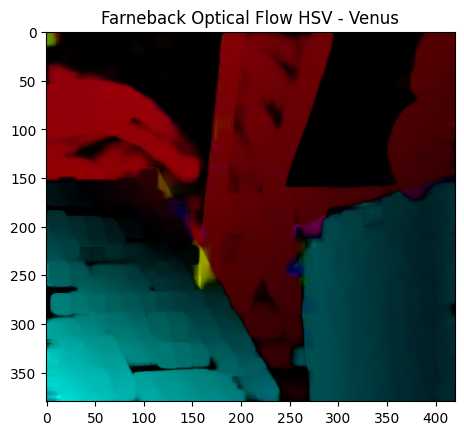

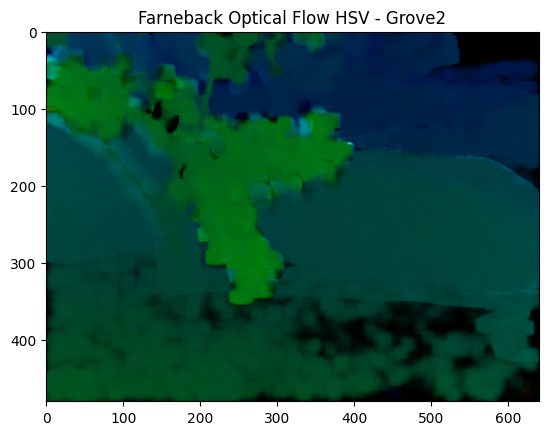

In [109]:
fb_flow1 = farneback(img11, img12)
fb_flow2 = farneback(img21, img22)
fb_flow3 = farneback(img31, img32)
fb_flow4 = farneback(img41, img42)
fb_flow5 = farneback(img51, img52)

visualize_flow_hsv(fb_flow1, "Farneback Optical Flow HSV - RubberWhale")
visualize_flow_hsv(fb_flow2, "Farneback Optical Flow HSV - Hydrangea")
visualize_flow_hsv(fb_flow3, "Farneback Optical Flow HSV - Urban2")
visualize_flow_hsv(fb_flow4, "Farneback Optical Flow HSV - Venus")
visualize_flow_hsv(fb_flow5, "Farneback Optical Flow HSV - Grove2")

Obrazy te gorzej oddają kształt obiektów niż wizualizacje przepływów przygotowanych przed ćwiczeniem.

In [110]:
def calculate_aee(predicted_flow, ground_truth_flow):
    """
    Oblicza Average Endpoint Error (AEE) pomiędzy przewidzianym a rzeczywistym polem przepływu.

    Args:
        predicted_flow (numpy.ndarray): Przewidziane pole przepływu (wysokość x szerokość x 2).
        ground_truth_flow (numpy.ndarray): Rzeczywiste pole przepływu (wysokość x szerokość x 2).

    Returns:
        float: Średni błąd AEE.
    """
    
    # Sprawdzenie czy ground_truth_flow jest None
    if ground_truth_flow is None:
        return np.nan

    h, w = predicted_flow.shape[:2]
    ground_truth_flow[ground_truth_flow[:, :, 0] > 100] = 0.0
    ground_truth_flow[ground_truth_flow[:, :, 1] > 100] = 0.0

   
    # Pomijamy piksele, dla których nie ma poprawnego przepływu (np. maska)
    #valid_pixels = (ground_truth_flow[:, :, 0] != 0) | (ground_truth_flow[:, :, 1] != 0) # Upewnij się, że maska jest poprawna
    u_diff = predicted_flow[:, :, 0] - ground_truth_flow[:, :, 0]
    v_diff = predicted_flow[:, :, 1] - ground_truth_flow[:, :, 1]
    aee = np.sqrt(u_diff**2 + v_diff**2)
    #aee = aee[valid_pixels] # uwzględnij tylko "dobre" piksele
    return np.mean(aee) if aee.size > 0 else 0  # obsługa przypadku, gdy valid_pixels jest puste

def calculate_angle_error(predicted_flow, ground_truth_flow):
    """
    Oblicza Angle Error (AE) pomiędzy przewidzianym a rzeczywistym polem przepływu.

    Args:
        predicted_flow (numpy.ndarray): Przewidziane pole przepływu (wysokość x szerokość x 2).
        ground_truth_flow (numpy.ndarray): Rzeczywiste pole przepływu (wysokość x szerokość x 2).

    Returns:
        float: Średni błąd AE w stopniach.
    """
    if ground_truth_flow is None:
        return np.nan

    h, w = predicted_flow.shape[:2]
    valid_pixels = (ground_truth_flow[:, :, 0] != 0) | (ground_truth_flow[:, :, 1] != 0)
    ground_truth_flow[ground_truth_flow[:, :, 0] > 100] = 0.0
    ground_truth_flow[ground_truth_flow[:, :, 1] > 100] = 0.0
    u1, v1 = predicted_flow[:, :, 0], predicted_flow[:, :, 1]
    u2, v2 = ground_truth_flow[:, :, 0], ground_truth_flow[:, :, 1]

    # Zapobiegaj dzieleniu przez zero
    norm1 = np.sqrt(u1**2 + v1**2)
    norm2 = np.sqrt(u2**2 + v2**2)
    norm1[norm1 == 0] = 1e-6
    norm2[norm2 == 0] = 1e-6

    cos_theta = (u1 * u2 + v1 * v2) / (norm1 * norm2)
    cos_theta = np.clip(cos_theta, -1, 1)  # Ogranicz wartości cosinusa
    angle_error = np.arccos(cos_theta) * 180 / np.pi
    angle_error = angle_error[valid_pixels]
    return np.mean(angle_error) if angle_error.size > 0 else 0

In [111]:
if gt_flow is not None:
    fb_aee = calculate_aee(fb_flow1, gt_flow1)
    fb_ae = calculate_angle_error(fb_flow1, gt_flow1)
    print(f"Farneback - {'RubberWhale':15} AEE: {fb_aee:.3f}, AE: {fb_ae:.3f}")

if gt_flow is not None:
    fb_aee = calculate_aee(fb_flow2, gt_flow2)
    fb_ae = calculate_angle_error(fb_flow2, gt_flow2)
    print(f"Farneback - {'Hydrangea':15} AEE: {fb_aee:.3f}, AE: {fb_ae:.3f}")

if gt_flow is not None:
    fb_aee = calculate_aee(fb_flow3, gt_flow3)
    fb_ae = calculate_angle_error(fb_flow3, gt_flow3)
    print(f"Farneback - {'Urban2':15} AEE: {fb_aee:.3f}, AE: {fb_ae:.3f}")

if gt_flow is not None:
    fb_aee = calculate_aee(fb_flow4, gt_flow4)
    fb_ae = calculate_angle_error(fb_flow4, gt_flow4)
    print(f"Farneback - {'Venus':15} AEE: {fb_aee:.3f}, AE: {fb_ae:.3f}")

if gt_flow is not None:
    fb_aee = calculate_aee(fb_flow5, gt_flow5)
    fb_ae = calculate_angle_error(fb_flow5, gt_flow5)
    print(f"Farneback - {'Grove2':15} AEE: {fb_aee:.3f}, AE: {fb_ae:.3f}")

Farneback - RubberWhale     AEE: 0.374, AE: 12.428
Farneback - Hydrangea       AEE: 0.787, AE: 3.234
Farneback - Urban2          AEE: 1.426, AE: 8.267
Farneback - Venus           AEE: 1.441, AE: 16.540
Farneback - Grove2          AEE: 0.583, AE: 5.329


Średni błąd końcowy wektora (AEE) jest mniejszy niż w przypadku Lucas-Kanade. Wartości ok. 1 sugerują także, że ta metoda dość dobrze radzi sobie z wyznaczaniem wielkości ruchu.

Błąd kierunku wektora przepływu (AE) wynoszący około od ok. 3 do ok. 16 stopni oznacza, że kierunek ruchu wyznaczony przez algorytm jest zbliżony do kierunku rzeczywistego, a działanie metody jest zadowalające.

Dla przypadku RubberWhale błąd odległości jest najniższy, jednak występuje tutaj jeden z najwyższych wartości błędu kierunku.

Przypadek Hydrangea, przedstawiająca krzew na jednolitym tle, daje bardzo niski błąd zarówno wielkości, jak i kierunku (najniższy), co wynika z prostoty sceny i wyraźnych struktur

Przypadek Urban2, będący ujęciem miasta z dużą liczbą szczegółów i niskim kontrastem, generuje większy błąd wielkości i kierunku, co jest oczekiwane przy tak złożonej teksturze. 

Przypadek Venus, czyli ujęcie z gazetami o dużej liczbie drobnych elementów i wysokim kontraście (tekst), powoduje wzrost błędu kierunku (najwyższy wynik), ponieważ algorytm musi radzić sobie z wieloma małymi, szybko zmieniającymi się strukturami.

Dla przypadku Grove2 sytuacja przedstawia się podobnie jak dla Hydrangea, ponieważ ten przypadek ilustruje drzewo, gdzie tło cechuje się dość niskim kontrastem (ziemia, kamienie).

Wyraźne i jednolite obiekty pierwszego planu pozwalają na minimalizację błędu wielkości ruchu, zaś jednolite tło pozwala na minimalizację błędu kierunku ruchu.

#### Analiza wpływu parametrów na wyniki obliczeń przepływu optycznego

Ze względu na mnogość przypadków scen i ilość parametrów, komentarze w analizie napisano wraz z następującą konwencją:
- opisano szczegółowo wpływ każdego parametru dla przypadku RubberWhale
- dla kolejnych przypadków komentowano jedynie odstępstwa od poprzednich wniosków lub inne ciekawe rzeczy

##### RubberWhale

In [112]:
print("\nEksperymenty z parametrami Farneback - RubberWhale:")
pyr_scales = [0.3, 0.8]
levels = [1, 7]
winsizes = [5, 7, 11, 15]
if gt_flow1 is not None:
    for ps in pyr_scales:
        for lvl in levels:
            for ws in winsizes :
                fb_flow = farneback(img11, img12, pyr_scale=ps, levels=lvl, winsize=ws)
                fb_aee = calculate_aee(fb_flow, gt_flow1)
                fb_ae = calculate_angle_error(fb_flow, gt_flow1)
                print(f"  pyr_scale={ps}, levels={lvl}, winsize={ws}: AEE={fb_aee:.3f}, AE={fb_ae:.3f}")


Eksperymenty z parametrami Farneback - RubberWhale:
  pyr_scale=0.3, levels=1, winsize=5: AEE=0.419, AE=10.810
  pyr_scale=0.3, levels=1, winsize=7: AEE=0.385, AE=10.347
  pyr_scale=0.3, levels=1, winsize=11: AEE=0.373, AE=11.219
  pyr_scale=0.3, levels=1, winsize=15: AEE=0.379, AE=12.521
  pyr_scale=0.3, levels=7, winsize=5: AEE=0.440, AE=11.057
  pyr_scale=0.3, levels=7, winsize=7: AEE=0.385, AE=10.348
  pyr_scale=0.3, levels=7, winsize=11: AEE=0.373, AE=11.219
  pyr_scale=0.3, levels=7, winsize=15: AEE=0.379, AE=12.520
  pyr_scale=0.8, levels=1, winsize=5: AEE=0.395, AE=10.342
  pyr_scale=0.8, levels=1, winsize=7: AEE=0.371, AE=10.136
  pyr_scale=0.8, levels=1, winsize=11: AEE=0.362, AE=11.022
  pyr_scale=0.8, levels=1, winsize=15: AEE=0.371, AE=12.357
  pyr_scale=0.8, levels=7, winsize=5: AEE=0.401, AE=10.355
  pyr_scale=0.8, levels=7, winsize=7: AEE=0.378, AE=10.237
  pyr_scale=0.8, levels=7, winsize=11: AEE=0.363, AE=11.027
  pyr_scale=0.8, levels=7, winsize=15: AEE=0.371, AE=12

Metoda Farnebacka działa najlepiej wtedy, gdy okno analizy jest większe, ponieważ daje to stabilniejszy i dokładniejszy przepływ, jednak przy dużej wielkości okna, wyniki zaczynają się pogarszać. To oznacza, że zbyt duże okno zaczyna rozmywać ruch.

Przy małych oknach lepsze wyniki pojawiają się przy płytszej piramidzie, natomiast przy większych oknach różnice między liczbą poziomów piramidy algorytmu Farneback zanikają. Oznacza to, że te parametry są ze sobą powiązane i wielkość okna oraz ilość warstw powinna być do siebie dostosowana.

Wyższy współczynnik skalowania, który określa, jak bardzo zmniejszany jest obraz na każdym kolejnym poziomie piramidy, poprawia jakość przepływu, ponieważ zachowuje więcej szczegółów obrazu i zmniejsza zniekształcenia w piramidzie.

In [113]:
print("\nEksperymenty z parametrami Farneback - RubberWhale:")
iterations_list = [3, 10]
poly_ns = [5, 7]
poly_sigmas = [1.1, 1.5]
if gt_flow1 is not None:
    for it in iterations_list:
        for pn in poly_ns:
            for psg in poly_sigmas:
                fb_flow = farneback(img11, img12, iterations=it, poly_n=pn, poly_sigma=psg)
                fb_aee = calculate_aee(fb_flow, gt_flow1)
                fb_ae = calculate_angle_error(fb_flow, gt_flow1)
                print(f"   iterations={it}, poly_n={pn}, poly_sigma={psg}: AEE={fb_aee:.3f}, AE={fb_ae:.3f}")



Eksperymenty z parametrami Farneback - RubberWhale:
   iterations=3, poly_n=5, poly_sigma=1.1: AEE=0.353, AE=12.239
   iterations=3, poly_n=5, poly_sigma=1.5: AEE=0.440, AE=13.087
   iterations=3, poly_n=7, poly_sigma=1.1: AEE=0.353, AE=12.239
   iterations=3, poly_n=7, poly_sigma=1.5: AEE=0.442, AE=13.095
   iterations=10, poly_n=5, poly_sigma=1.1: AEE=0.348, AE=12.118
   iterations=10, poly_n=5, poly_sigma=1.5: AEE=0.439, AE=13.070
   iterations=10, poly_n=7, poly_sigma=1.1: AEE=0.348, AE=12.118
   iterations=10, poly_n=7, poly_sigma=1.5: AEE=0.441, AE=13.078


Wartości błędów są najniższe wtedy, gdy poly_sigma jest mniejsze, ponieważ mniejsza dewiacja standardowa w filtrze Gaussa oznacza słabsze wygładzanie, a to pozwala zachować więcej lokalnych szczegółów i poprawniej odwzorować zmiany intensywności, które są kluczowe dla dokładnego wyznaczania przepływu. Nie oznacza to koniecznie, że brak rozmycia byłby korzystny. Rozmycie jest konieczne do usunięcia zbędnych szczegółów, aby algorytm był bardziej efektywny.

Niższe poly_n, czyli mniejsza liczba pikseli używana do aproksymacji wielomianu przybliżającego fragment obrazu, również poprawia wynik, ponieważ mniejszy obszar lokalny lepiej dopasowuje się do drobnych struktur obrazu i nie rozmywa ruchu. 

Większa liczba iteracji poprawia zbieżność algorytmu, dzięki czemu kolejne przybliżenia przepływu są bardziej precyzyjne i lepiej dopasowane do rzeczywistego ruchu.

##### Hydrangea

In [114]:
print("\nEksperymenty z parametrami Farneback - Hydrangea:")
pyr_scales = [0.3, 0.8]
levels = [1, 7]
winsizes = [5, 7, 11, 15]
if gt_flow2 is not None:
    for ps in pyr_scales:
        for lvl in levels:
            for ws in winsizes :
                fb_flow = farneback(img21, img22, pyr_scale=ps, levels=lvl, winsize=ws)
                fb_aee = calculate_aee(fb_flow, gt_flow2)
                fb_ae = calculate_angle_error(fb_flow, gt_flow2)
                print(f"  pyr_scale={ps}, levels={lvl}, winsize={ws}: AEE={fb_aee:.3f}, AE={fb_ae:.3f}")


Eksperymenty z parametrami Farneback - Hydrangea:
  pyr_scale=0.3, levels=1, winsize=5: AEE=0.979, AE=5.263
  pyr_scale=0.3, levels=1, winsize=7: AEE=0.868, AE=3.822
  pyr_scale=0.3, levels=1, winsize=11: AEE=0.798, AE=3.199
  pyr_scale=0.3, levels=1, winsize=15: AEE=0.790, AE=3.240
  pyr_scale=0.3, levels=7, winsize=5: AEE=0.980, AE=5.262
  pyr_scale=0.3, levels=7, winsize=7: AEE=0.868, AE=3.822
  pyr_scale=0.3, levels=7, winsize=11: AEE=0.798, AE=3.196
  pyr_scale=0.3, levels=7, winsize=15: AEE=0.791, AE=3.239
  pyr_scale=0.8, levels=1, winsize=5: AEE=1.295, AE=12.049
  pyr_scale=0.8, levels=1, winsize=7: AEE=1.019, AE=6.816
  pyr_scale=0.8, levels=1, winsize=11: AEE=0.877, AE=4.775
  pyr_scale=0.8, levels=1, winsize=15: AEE=0.839, AE=4.346
  pyr_scale=0.8, levels=7, winsize=5: AEE=0.938, AE=4.409
  pyr_scale=0.8, levels=7, winsize=7: AEE=0.851, AE=3.577
  pyr_scale=0.8, levels=7, winsize=11: AEE=0.793, AE=3.184
  pyr_scale=0.8, levels=7, winsize=15: AEE=0.787, AE=3.231


Dla tego przypadku nie zaobserwowano pogorszenia wielkości błędów wraz ze zwiększeniem okna, oznacza to, że wielkość okna trzeba wybierać indywidualnie dla każdego przypadku i nie ma jedynej słusznej wartości.

In [120]:
print("\nEksperymenty z parametrami Farneback - Hydrangea:")
iterations_list = [3, 10]
poly_ns = [5, 7]
poly_sigmas = [1.1, 1.5]
if gt_flow2 is not None:
    for it in iterations_list:
        for pn in poly_ns:
            for psg in poly_sigmas:
                fb_flow = farneback(img21, img22, iterations=it, poly_n=pn, poly_sigma=psg)
                fb_aee = calculate_aee(fb_flow, gt_flow2)
                fb_ae = calculate_angle_error(fb_flow, gt_flow2)
                print(f"   iterations={it}, poly_n={pn}, poly_sigma={psg}: AEE={fb_aee:.3f}, AE={fb_ae:.3f}")


Eksperymenty z parametrami Farneback - Hydrangea:
   iterations=3, poly_n=5, poly_sigma=1.1: AEE=0.701, AE=3.205
   iterations=3, poly_n=5, poly_sigma=1.5: AEE=1.334, AE=3.381
   iterations=3, poly_n=7, poly_sigma=1.1: AEE=0.701, AE=3.205
   iterations=3, poly_n=7, poly_sigma=1.5: AEE=1.365, AE=3.391
   iterations=10, poly_n=5, poly_sigma=1.1: AEE=0.699, AE=3.198
   iterations=10, poly_n=5, poly_sigma=1.5: AEE=1.332, AE=3.381
   iterations=10, poly_n=7, poly_sigma=1.1: AEE=0.699, AE=3.198
   iterations=10, poly_n=7, poly_sigma=1.5: AEE=1.363, AE=3.390


Dla tego przypadku wpływ liczby iteracji nie był aż tak znaczący. Może tak być, ponieważ był to dość prosty obraz - jeden obiekt, jednolite tło.

##### Urban2

In [115]:
print("\nEksperymenty z parametrami Farneback - Urban2:")
pyr_scales = [0.3, 0.8]
levels = [1, 7]
winsizes = [5, 7, 11, 15]
if gt_flow3 is not None:
    for ps in pyr_scales:
        for lvl in levels:
            for ws in winsizes :
                fb_flow = farneback(img31, img32, pyr_scale=ps, levels=lvl, winsize=ws)
                fb_aee = calculate_aee(fb_flow, gt_flow3)
                fb_ae = calculate_angle_error(fb_flow, gt_flow3)
                print(f"  pyr_scale={ps}, levels={lvl}, winsize={ws}: AEE={fb_aee:.3f}, AE={fb_ae:.3f}")


Eksperymenty z parametrami Farneback - Urban2:
  pyr_scale=0.3, levels=1, winsize=5: AEE=6.291, AE=34.145
  pyr_scale=0.3, levels=1, winsize=7: AEE=5.918, AE=30.724
  pyr_scale=0.3, levels=1, winsize=11: AEE=5.673, AE=29.000
  pyr_scale=0.3, levels=1, winsize=15: AEE=5.160, AE=22.866
  pyr_scale=0.3, levels=7, winsize=5: AEE=3.140, AE=16.978
  pyr_scale=0.3, levels=7, winsize=7: AEE=2.289, AE=12.756
  pyr_scale=0.3, levels=7, winsize=11: AEE=1.653, AE=9.222
  pyr_scale=0.3, levels=7, winsize=15: AEE=1.399, AE=8.111
  pyr_scale=0.8, levels=1, winsize=5: AEE=7.955, AE=45.493
  pyr_scale=0.8, levels=1, winsize=7: AEE=7.650, AE=42.531
  pyr_scale=0.8, levels=1, winsize=11: AEE=7.470, AE=40.277
  pyr_scale=0.8, levels=1, winsize=15: AEE=7.401, AE=39.566
  pyr_scale=0.8, levels=7, winsize=5: AEE=5.237, AE=26.454
  pyr_scale=0.8, levels=7, winsize=7: AEE=5.117, AE=25.081
  pyr_scale=0.8, levels=7, winsize=11: AEE=4.018, AE=19.485
  pyr_scale=0.8, levels=7, winsize=15: AEE=3.029, AE=14.524


Dla tego przypadku osiągnięto gorsze wyniki dla większej wartości współczynnika skalowania. Scena ma mnóstwo drobnych detali, cienkich krawędzi, szumu i chaotycznych struktur (miasto). Przy wysokim pyr_scale kolejne poziomy piramidy są zbyt podobne do oryginału, duże przesunięcia pikseli nie są wystarczająco redukowane w piramidzie, więc algorytm musi estymować bardzo duży ruch na prawie pełnej rozdzielczości, co prowadzi do niestabilnych i niedokładnych wektorów przepływu.

In [121]:
print("\nEksperymenty z parametrami Farneback - Urban2:")
iterations_list = [3, 10]
poly_ns = [5, 7]
poly_sigmas = [1.1, 1.5]
if gt_flow3 is not None:
    for it in iterations_list:
        for pn in poly_ns:
            for psg in poly_sigmas:
                fb_flow = farneback(img31, img32, iterations=it, poly_n=pn, poly_sigma=psg)
                fb_aee = calculate_aee(fb_flow, gt_flow3)
                fb_ae = calculate_angle_error(fb_flow, gt_flow3)
                print(f"   iterations={it}, poly_n={pn}, poly_sigma={psg}: AEE={fb_aee:.3f}, AE={fb_ae:.3f}")


Eksperymenty z parametrami Farneback - Urban2:
   iterations=3, poly_n=5, poly_sigma=1.1: AEE=1.222, AE=8.028
   iterations=3, poly_n=5, poly_sigma=1.5: AEE=2.571, AE=11.466
   iterations=3, poly_n=7, poly_sigma=1.1: AEE=1.222, AE=8.028
   iterations=3, poly_n=7, poly_sigma=1.5: AEE=2.639, AE=11.634
   iterations=10, poly_n=5, poly_sigma=1.1: AEE=1.344, AE=8.710
   iterations=10, poly_n=5, poly_sigma=1.5: AEE=3.207, AE=15.285
   iterations=10, poly_n=7, poly_sigma=1.1: AEE=1.343, AE=8.707
   iterations=10, poly_n=7, poly_sigma=1.5: AEE=3.266, AE=15.605


Wyniki uzyskano gorsze dla większej liczby iteracji.

##### Venus

In [116]:
print("\nEksperymenty z parametrami Farneback - Venus:")
pyr_scales = [0.3, 0.8]
levels = [1, 7]
winsizes = [5, 7, 11, 15]
if gt_flow4 is not None:
    for ps in pyr_scales:
        for lvl in levels:
            for ws in winsizes :
                fb_flow = farneback(img41, img42, pyr_scale=ps, levels=lvl, winsize=ws)
                fb_aee = calculate_aee(fb_flow, gt_flow4)
                fb_ae = calculate_angle_error(fb_flow, gt_flow4)
                print(f"  pyr_scale={ps}, levels={lvl}, winsize={ws}: AEE={fb_aee:.3f}, AE={fb_ae:.3f}")


Eksperymenty z parametrami Farneback - Venus:
  pyr_scale=0.3, levels=1, winsize=5: AEE=1.916, AE=23.931
  pyr_scale=0.3, levels=1, winsize=7: AEE=1.772, AE=20.710
  pyr_scale=0.3, levels=1, winsize=11: AEE=1.579, AE=18.047
  pyr_scale=0.3, levels=1, winsize=15: AEE=1.460, AE=17.081
  pyr_scale=0.3, levels=7, winsize=5: AEE=1.934, AE=23.760
  pyr_scale=0.3, levels=7, winsize=7: AEE=1.772, AE=20.710
  pyr_scale=0.3, levels=7, winsize=11: AEE=1.579, AE=18.053
  pyr_scale=0.3, levels=7, winsize=15: AEE=1.460, AE=17.082
  pyr_scale=0.8, levels=1, winsize=5: AEE=2.998, AE=31.556
  pyr_scale=0.8, levels=1, winsize=7: AEE=2.363, AE=26.757
  pyr_scale=0.8, levels=1, winsize=11: AEE=1.887, AE=21.552
  pyr_scale=0.8, levels=1, winsize=15: AEE=1.658, AE=18.903
  pyr_scale=0.8, levels=7, winsize=5: AEE=1.878, AE=22.605
  pyr_scale=0.8, levels=7, winsize=7: AEE=1.726, AE=19.455
  pyr_scale=0.8, levels=7, winsize=11: AEE=1.534, AE=16.861
  pyr_scale=0.8, levels=7, winsize=15: AEE=1.414, AE=16.006


W tym wypadku widać, że dla małego współczynnika skalowania ilość poziomów piramidy była praktycznie bez znaczenia, a przy dużym współczynniku skalowania, zwiększenie ilości poziomów znacznie polepszyło wyniki. STało się tak, ponieważ przy wysokim wsp. skalowania, gdzie kolejne poziomy piramidy są do siebie podobne, ich większa ilość pozwala na lepszą redukcję wysokoczęstotliwościowych detali.

In [122]:
print("\nEksperymenty z parametrami Farneback - Venus:")
iterations_list = [3, 10]
poly_ns = [5, 7]
poly_sigmas = [1.1, 1.5]
if gt_flow1 is not None:
    for it in iterations_list:
        for pn in poly_ns:
            for psg in poly_sigmas:
                fb_flow = farneback(img11, img12, iterations=it, poly_n=pn, poly_sigma=psg)
                fb_aee = calculate_aee(fb_flow, gt_flow1)
                fb_ae = calculate_angle_error(fb_flow, gt_flow1)
                print(f"   iterations={it}, poly_n={pn}, poly_sigma={psg}: AEE={fb_aee:.3f}, AE={fb_ae:.3f}")


Eksperymenty z parametrami Farneback - Venus:
   iterations=3, poly_n=5, poly_sigma=1.1: AEE=0.353, AE=12.239
   iterations=3, poly_n=5, poly_sigma=1.5: AEE=0.440, AE=13.087
   iterations=3, poly_n=7, poly_sigma=1.1: AEE=0.353, AE=12.239
   iterations=3, poly_n=7, poly_sigma=1.5: AEE=0.442, AE=13.095
   iterations=10, poly_n=5, poly_sigma=1.1: AEE=0.348, AE=12.118
   iterations=10, poly_n=5, poly_sigma=1.5: AEE=0.439, AE=13.070
   iterations=10, poly_n=7, poly_sigma=1.1: AEE=0.348, AE=12.118
   iterations=10, poly_n=7, poly_sigma=1.5: AEE=0.441, AE=13.078


##### Grove2

In [118]:
print("\nEksperymenty z parametrami Farneback - Grove2:")
pyr_scales = [0.3, 0.8]
levels = [1, 7]
winsizes = [5, 7, 11, 15]
if gt_flow5 is not None:
    for ps in pyr_scales:
        for lvl in levels:
            for ws in winsizes :
                fb_flow = farneback(img51, img52, pyr_scale=ps, levels=lvl, winsize=ws)
                fb_aee = calculate_aee(fb_flow, gt_flow5)
                fb_ae = calculate_angle_error(fb_flow, gt_flow5)
                print(f"  pyr_scale={ps}, levels={lvl}, winsize={ws}: AEE={fb_aee:.3f}, AE={fb_ae:.3f}")


Eksperymenty z parametrami Farneback - Grove2:
  pyr_scale=0.3, levels=1, winsize=5: AEE=0.849, AE=9.958
  pyr_scale=0.3, levels=1, winsize=7: AEE=0.738, AE=7.699
  pyr_scale=0.3, levels=1, winsize=11: AEE=0.627, AE=5.875
  pyr_scale=0.3, levels=1, winsize=15: AEE=0.584, AE=5.398
  pyr_scale=0.3, levels=7, winsize=5: AEE=0.859, AE=9.979
  pyr_scale=0.3, levels=7, winsize=7: AEE=0.738, AE=7.698
  pyr_scale=0.3, levels=7, winsize=11: AEE=0.627, AE=5.874
  pyr_scale=0.3, levels=7, winsize=15: AEE=0.584, AE=5.398
  pyr_scale=0.8, levels=1, winsize=5: AEE=0.993, AE=13.104
  pyr_scale=0.8, levels=1, winsize=7: AEE=0.805, AE=8.921
  pyr_scale=0.8, levels=1, winsize=11: AEE=0.630, AE=5.969
  pyr_scale=0.8, levels=1, winsize=15: AEE=0.573, AE=5.159
  pyr_scale=0.8, levels=7, winsize=5: AEE=0.790, AE=7.849
  pyr_scale=0.8, levels=7, winsize=7: AEE=0.689, AE=5.995
  pyr_scale=0.8, levels=7, winsize=11: AEE=0.596, AE=4.866
  pyr_scale=0.8, levels=7, winsize=15: AEE=0.559, AE=4.715


In [123]:
print("\nEksperymenty z parametrami Farneback - Grove2:")
iterations_list = [3, 10]
poly_ns = [5, 7]
poly_sigmas = [1.1, 1.5]
if gt_flow5 is not None:
    for it in iterations_list:
        for pn in poly_ns:
            for psg in poly_sigmas:
                fb_flow = farneback(img51, img52, iterations=it, poly_n=pn, poly_sigma=psg)
                fb_aee = calculate_aee(fb_flow, gt_flow5)
                fb_ae = calculate_angle_error(fb_flow, gt_flow5)
                print(f"   iterations={it}, poly_n={pn}, poly_sigma={psg}: AEE={fb_aee:.3f}, AE={fb_ae:.3f}")


Eksperymenty z parametrami Farneback - Grove2:
   iterations=3, poly_n=5, poly_sigma=1.1: AEE=0.485, AE=4.924
   iterations=3, poly_n=5, poly_sigma=1.5: AEE=0.949, AE=5.692
   iterations=3, poly_n=7, poly_sigma=1.1: AEE=0.485, AE=4.924
   iterations=3, poly_n=7, poly_sigma=1.5: AEE=0.960, AE=5.719
   iterations=10, poly_n=5, poly_sigma=1.1: AEE=0.480, AE=4.727
   iterations=10, poly_n=5, poly_sigma=1.5: AEE=0.939, AE=5.620
   iterations=10, poly_n=7, poly_sigma=1.1: AEE=0.480, AE=4.727
   iterations=10, poly_n=7, poly_sigma=1.5: AEE=0.950, AE=5.644


Dla tego przypadku wartość dewiacji standardowej była istotnym czynnikiem wpływającym na wartości AEE.

##### Podsumowanie

Nie ma optymalnych wartości dla każdego przypadku, chociaż wartości domyślne dały zadowalające wyniki. Dobór parametrów musi być przeprowadzany indywidualnie dla sceny. 

## 3. RAFT

In [124]:
from PIL import Image
import torch
import torchvision
import gc

In [125]:
device = "cuda" if torch.cuda.is_available() else "cpu"

torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [138]:
from torchvision.models.optical_flow import raft_large
from torchvision.models.optical_flow import Raft_Large_Weights

from torchvision.models.optical_flow import raft_small
from torchvision.models.optical_flow import Raft_Small_Weights

def compute_flow_raft(model, path1, path2, device):
    # Load images
    img1 = Image.open(path1)
    img2 = Image.open(path2)

    # Convert to numpy
    img1 = np.array(img1)
    img2 = np.array(img2)

    # Crop to height 384 (jak w Twoim kodzie)
    img1 = img1[0:384, :]
    img2 = img2[0:384, :]

    # Normalize to [-1, 1]
    img1 = img1.astype(np.float32) / 127.5 - 1.0
    img2 = img2.astype(np.float32) / 127.5 - 1.0

    # Convert to CHW and add batch dimension
    img1 = img1.transpose(2, 0, 1)[None]
    img2 = img2.transpose(2, 0, 1)[None]

    # Convert to tensors
    t1 = torch.tensor(img1).to(device)
    t2 = torch.tensor(img2).to(device)

    # Run RAFT
    with torch.no_grad():
        flow_list = model(t1, t2)
        flow = flow_list[-1][0].cpu().numpy()

    # Convert to HWC
    flow = flow.transpose(1, 2, 0)

    return flow

In [141]:
model = raft_large(weights=Raft_Large_Weights.DEFAULT, progress=False).to(device)
model = model.eval()

flow11 = compute_flow_raft(model, image1_path1, image1_path2, device)
flow12 = compute_flow_raft(model, image2_path1, image2_path2, device)
flow13 = compute_flow_raft(model, image3_path1, image3_path2, device)
#flow14 = compute_flow_raft(model, image4_path1, image4_path2, device)  ValueError: input image H and W should be divisible by 8, instead got 380 (h) and 420 (w)
flow15 = compute_flow_raft(model, image5_path1, image5_path2, device)

# Release Memory after Prediction
del model
gc.collect()
torch.cuda.empty_cache()

print(flow11.shape)
print(flow12.shape)
print(flow13.shape)
#print(flow14.shape)
print(flow15.shape)


(384, 584, 2)
(384, 584, 2)
(384, 640, 2)
(384, 640, 2)


Dla przypadku Venus H i W nie są podzielne przez 8, więc nie rozpatrywano tego przypadku niżej, ze względu na błąd kompilacji.

In [142]:
model = raft_small(weights=Raft_Small_Weights.DEFAULT, progress=False).to(device)
model = model.eval()

flow21 = compute_flow_raft(model, image1_path1, image1_path2, device)
flow22 = compute_flow_raft(model, image2_path1, image2_path2, device)
flow23 = compute_flow_raft(model, image3_path1, image3_path2, device)
#flow24 = compute_flow_raft(model, image4_path1, image4_path2, device)  ValueError: input image H and W should be divisible by 8, instead got 380 (h) and 420 (w)
flow25 = compute_flow_raft(model, image5_path1, image5_path2, device)

# Release Memory after Prediction
del model
gc.collect()
torch.cuda.empty_cache()

print(flow21.shape)
print(flow22.shape)
print(flow23.shape)
#print(flow24.shape)
print(flow5.shape)

(384, 584, 2)
(384, 584, 2)
(384, 640, 2)
(384, 640, 2)


In [143]:
import flow_vis

flow_viz11 = []
flow_viz11 = flow_vis.flow_to_color(flow11)
flow_viz12 = []
flow_viz12 = flow_vis.flow_to_color(flow12)
flow_viz13 = []
flow_viz13 = flow_vis.flow_to_color(flow13)
flow_viz15 = []
flow_viz15 = flow_vis.flow_to_color(flow15)
flow_viz21 = []
flow_viz21 = flow_vis.flow_to_color(flow21)
flow_viz22 = []
flow_viz22 = flow_vis.flow_to_color(flow22)
flow_viz23 = []
flow_viz23 = flow_vis.flow_to_color(flow23)
flow_viz25 = []
flow_viz25 = flow_vis.flow_to_color(flow25)

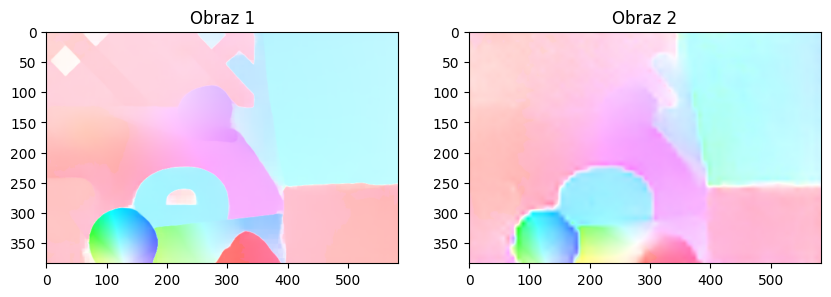

In [145]:
visualize_images(flow_viz11, flow_viz21)

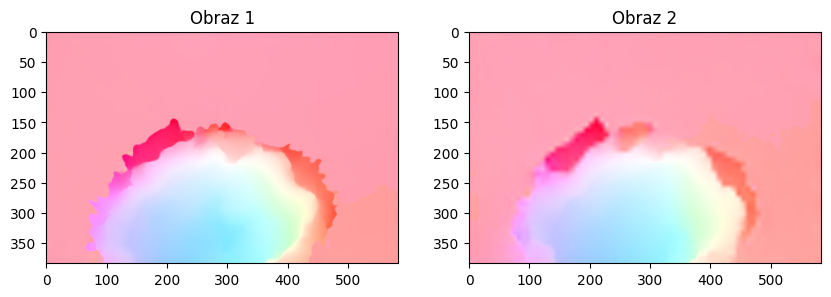

In [146]:
visualize_images(flow_viz12, flow_viz22)

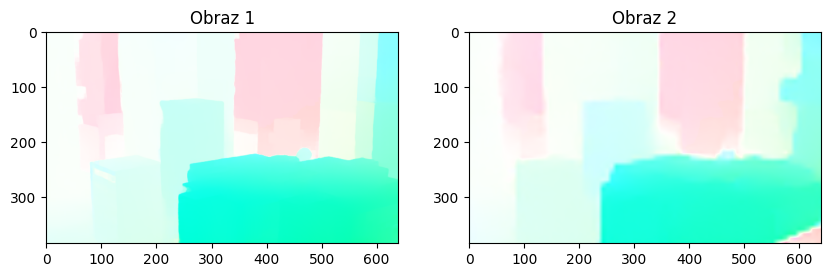

In [147]:
visualize_images(flow_viz13, flow_viz23)

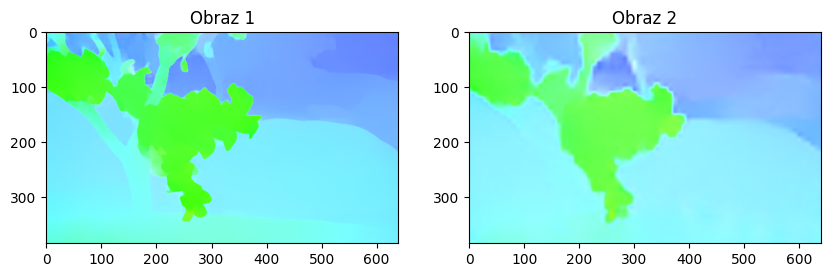

In [148]:
visualize_images(flow_viz15, flow_viz25)

Dla modelu large obrazy są bardziej wyraźne.

In [153]:
if gt_flow1 is not None:
    raft_aee = calculate_aee(flow11, gt_flow1[0:384,:])
    raft_ae = calculate_angle_error(flow11, gt_flow1[0:384,:])
    print(f"RAFT LARGE - {'RubberWhale':15} AEE: {raft_aee:.3f}, AE: {raft_ae:.3f}")

if gt_flow1 is not None:
    raft_aee = calculate_aee(flow21, gt_flow1[0:384,:])
    raft_ae = calculate_angle_error(flow1, gt_flow1[0:384,:])
    print(f"RAFT SMALL - {'RubberWhale':15} AEE: {raft_aee:.3f}, AE: {raft_ae:.3f}")

if gt_flow2 is not None:
    raft_aee = calculate_aee(flow12, gt_flow2[0:384,:])
    raft_ae = calculate_angle_error(flow12, gt_flow2[0:384,:])
    print(f"RAFT LARGE - {'Hydrangea':15} AEE: {raft_aee:.3f}, AE: {raft_ae:.3f}")

if gt_flow2 is not None:
    raft_aee = calculate_aee(flow22, gt_flow2[0:384,:])
    raft_ae = calculate_angle_error(flow22, gt_flow2[0:384,:])
    print(f"RAFT SMALL - {'Hydrangea':15} AEE: {raft_aee:.3f}, AE: {raft_ae:.3f}")

if gt_flow3 is not None:
    raft_aee = calculate_aee(flow13, gt_flow3[0:384,:])
    raft_ae = calculate_angle_error(flow13, gt_flow3[0:384,:])
    print(f"RAFT LARGE - {'Urban2':15} AEE: {raft_aee:.3f}, AE: {raft_ae:.3f}")

if gt_flow3 is not None:
    raft_aee = calculate_aee(flow23, gt_flow3[0:384,:])
    raft_ae = calculate_angle_error(flow23, gt_flow3[0:384,:])
    print(f"RAFT SMALL - {'Urban2':15} AEE: {raft_aee:.3f}, AE: {raft_ae:.3f}")

if gt_flow5 is not None:
    raft_aee = calculate_aee(flow15, gt_flow5[0:384,:])
    raft_ae = calculate_angle_error(flow15, gt_flow5[0:384,:])
    print(f"RAFT LARGE - {'Grove2':15} AEE: {raft_aee:.3f}, AE: {raft_ae:.3f}")

if gt_flow5 is not None:
    raft_aee = calculate_aee(flow25, gt_flow5[0:384,:])
    raft_ae = calculate_angle_error(flow25, gt_flow5[0:384,:])
    print(f"RAFT SMALL - {'Grove2':15} AEE: {raft_aee:.3f}, AE: {raft_ae:.3f}")

RAFT LARGE - RubberWhale     AEE: 0.191, AE: 8.213
RAFT SMALL - RubberWhale     AEE: 0.369, AE: 15.954
RAFT LARGE - Hydrangea       AEE: 0.438, AE: 2.795
RAFT SMALL - Hydrangea       AEE: 0.558, AE: 3.956
RAFT LARGE - Urban2          AEE: 0.287, AE: 4.326
RAFT SMALL - Urban2          AEE: 0.726, AE: 7.320
RAFT LARGE - Grove2          AEE: 0.242, AE: 3.515
RAFT SMALL - Grove2          AEE: 0.406, AE: 6.026


Dla modelu RAFT large wartości błędów są niższe niż dla modelu RAFT small.

Wyniki dla Farneback:
- Farneback - RubberWhale     AEE: 0.374, AE: 12.428
- Farneback - Hydrangea       AEE: 0.787, AE: 3.234
- Farneback - Urban2          AEE: 1.426, AE: 8.267
- Farneback - Venus           AEE: 1.441, AE: 16.540
- Farneback - Grove2          AEE: 0.583, AE: 5.329

Model RAFT large w każdym przypadku pozwolił na osiągnięcie lepszych wyników niż algorytm Farneback. W niektórych przypadkach Farneback pozwolił na uzyskanie lepszych wyników AE niż model RAFT small.

RAFT large ma znacznie większą pojemność modelu, więc lepiej odwzorowuje złożone przepływy.

RAFT small jest lżejszy i mniej precyzyjny, więc w scenach z małymi, lokalnymi ruchami może przegrywać z Farnebackiem, który w takich warunkach działa bardzo stabilnie.

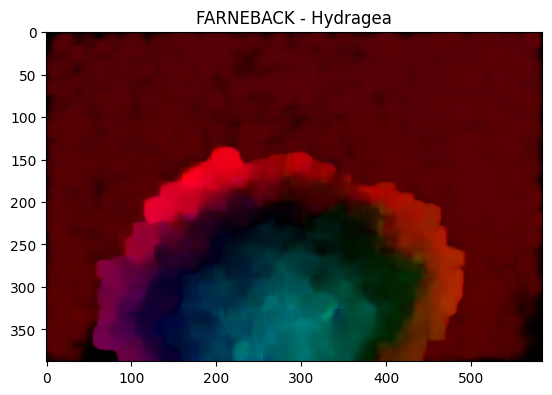

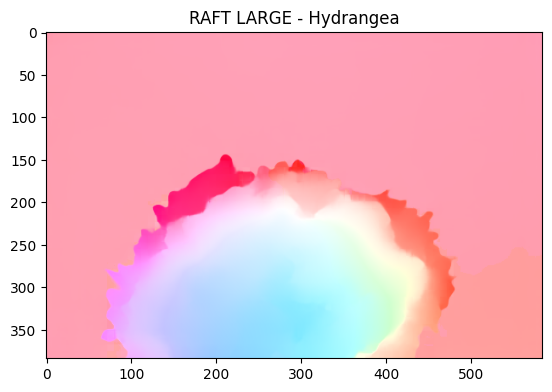

In [160]:
visualize_flow_hsv(fb_flow2, "FARNEBACK - Hydragea")

plt.imshow(flow_viz12)
plt.title("RAFT LARGE - Hydrangea")
plt.show()

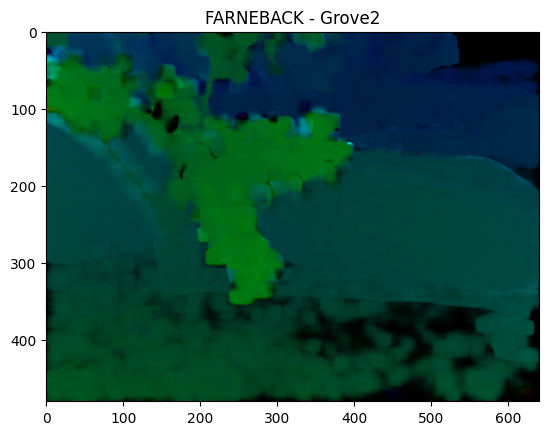

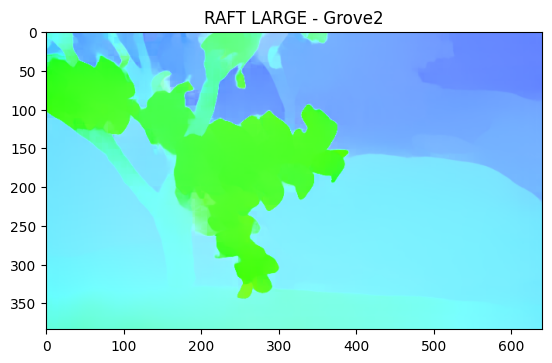

In [159]:
visualize_flow_hsv(fb_flow5, "FARNEBACK - Grove2")

plt.imshow(flow_viz15)
plt.title("RAFT LARGE - Grove2")
plt.show()

Powyżej przedstawiono porównanie wizualne przepływów o najmniejszych wartościach błędów dla metody Farneback i modelu RAFT large.

Model RAF large generuje bardziej ciągły i fizycznie spójny przepływ, co przekłada się na niższe błędy AEE i AE.

Farneback, traci dokładność w obszarach o dużych ruchach i złożonej teksturze.